# 1. Collecting Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install fsspec huggingface_hub pyarrow

In [3]:
!pip install datasets

In [4]:
from datasets import load_dataset

dataset = load_dataset("vicgalle/alpaca-gpt4")
df = dataset['train'].to_pandas()

C:\Users\Shobhit Sharma\Anaconda3\envs\ds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df.head()

,instruction,input,output,text
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....
2,Describe the structure of an atom.,,An atom is the basic building block of all mat...,Below is an instruction that describes a task....
3,How can we reduce air pollution?,,There are several ways to reduce air pollution...,Below is an instruction that describes a task....
4,Describe a time when you had to make a difficu...,,"As an AI assistant, I do not have my own perso...",Below is an instruction that describes a task....


In [6]:
type(df)

pandas.core.frame.DataFrame

In [7]:
df.shape

(52002, 4)

# 2. What do people ask ChatGPT most often?

In [8]:
!pip install nltk
!pip install re

ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re


In [9]:
import nltk

In [10]:
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words=stopwords.words("english")

[nltk_data] Downloading package stopwords to C:\Users\Shobhit
[nltk_data]     Sharma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
len(stop_words)

198

In [12]:
custom_stopwords = [
    # Common instruction verbs
    'write', 'generate', 'create', 'give', 'list', 'describe', 'explain',
    'provide', 'make', 'find', 'identify', 'suggest', 'classify', 'rewrite',
    'summarize', 'compare', 'construct', 'edit',

    # Prompt structure words
    'following', 'given', 'using', 'based', 'text', 'sentence', 'sentences',
    'paragraph', 'article', 'statement', 'example', 'words', 'word', 'name',
    'phrase', 'output', 'input',

    # Generic verbs / fillers
    'use', 'used', 'way', 'come', 'make',

    # Generic adjectives
    'new', 'different', 'various', 'type', 'kind',

    # Numbers often used in prompts
    'one', 'two', 'three', 'four', 'five', 'first', 'second', 'third',
    '1', '2', '3', '4', '5', '10', 'number', 'numbers'
]

In [13]:
stop_words.extend(custom_stopwords)

In [14]:
len(stop_words)

259

### 2.1 Cleaning the prompts

In [15]:
import re

In [16]:
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r'[^a-z\s]','',text)
    return text

In [17]:
df.columns

Index(['instruction', 'input', 'output', 'text'], dtype='object')

In [18]:
cleaned_text=df["instruction"].apply(clean_text)
cleaned_text

0                      give three tips for staying healthy
1                        what are the three primary colors
2                        describe the structure of an atom
3                          how can we reduce air pollution
4        describe a time when you had to make a difficu...
                               ...                        
51997    generate an example of what a resume should li...
51998    arrange the items given below in the order to ...
51999    write an introductory paragraph about a famous...
52000    generate a list of five things one should keep...
52001    analyze the given legal document and explain t...
Name: instruction, Length: 52002, dtype: object

### 2.2 WordCloud

In [19]:
type(cleaned_text)

pandas.core.series.Series

In [20]:
all_text=" ".join(cleaned_text)

In [21]:
!pip install wordcloud

In [22]:
from wordcloud import WordCloud
wc=WordCloud(width=1200,
         height=600,stopwords=stop_words).generate(all_text)

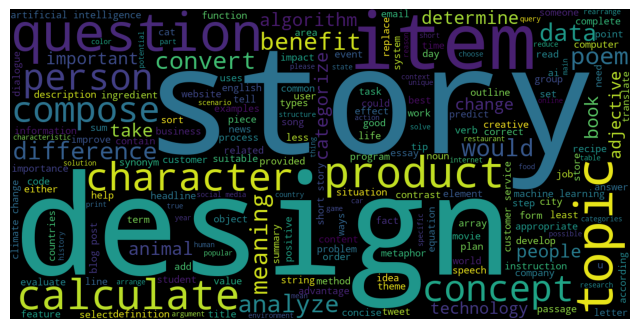

In [23]:
plt.figure(figsize=(8,5))
plt.imshow(wc)
plt.axis("off")

plt.savefig("word_cloud.png", bbox_inches='tight', pad_inches=0, transparent=True)

# 3. Analyzing Prompts

In [24]:
df.head()

,instruction,input,output,text
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....
2,Describe the structure of an atom.,,An atom is the basic building block of all mat...,Below is an instruction that describes a task....
3,How can we reduce air pollution?,,There are several ways to reduce air pollution...,Below is an instruction that describes a task....
4,Describe a time when you had to make a difficu...,,"As an AI assistant, I do not have my own perso...",Below is an instruction that describes a task....


In [25]:
def categorise_prompts(text):
    text_lower = text.lower()

    if text_lower.startswith(('can you', 'could you', 'would you', 'do you', 'did you', 'is it', 'are there', 'should i')):
        return 'Question'
    
    elif text_lower.startswith(('write', 'create', 'generate', 'compose', 'draft')):
        return 'Creative Task'
    
    elif text_lower.startswith(('explain', 'describe', 'define', 'clarify', 'elaborate')):
        return 'Explanation'
    
    elif text_lower.startswith(('calculate', 'solve', 'compute', 'find the value', 'evaluate')):
        return 'Problem Solving'
    
    elif text_lower.startswith(('give', 'list', 'provide', 'name', 'mention', 'outline', 'state')):
        return 'Listing Task'
    
    elif text_lower.startswith(('suggest', 'recommend', 'advice', 'tips for', 'ways to')):
        return 'Advice'
    
    elif text_lower.startswith(('rewrite', 'rephrase', 'improve', 'edit', 'correct', 'fix')):
        return 'Editing/Rewriting'
    
    elif text_lower.startswith(('classify', 'categorize', 'group the following', 'label the following')):
        return 'Classification'
    
    else:
        return 'Other'

In [26]:
#removing whitespaces from prompts
df["instruction"]=df["instruction"].str.strip()

In [27]:
df["prompt_type"]=df["instruction"].apply(categorise_prompts)

In [28]:
df[["instruction","prompt_type"]]

,instruction,prompt_type
0,Give three tips for staying healthy.,Listing Task
1,What are the three primary colors?,Other
2,Describe the structure of an atom.,Explanation
3,How can we reduce air pollution?,Other
4,Describe a time when you had to make a difficu...,Explanation
...,...,...
51997,Generate an example of what a resume should li...,Creative Task
51998,Arrange the items given below in the order to ...,Other
51999,Write an introductory paragraph about a famous...,Creative Task
52000,Generate a list of five things one should keep...,Creative Task


<Axes: xlabel='prompt_type'>

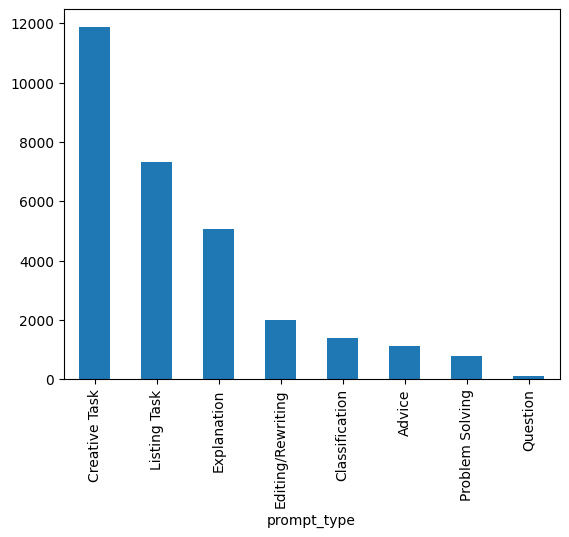

In [29]:
df["prompt_type"].value_counts()[1:].plot(kind="bar")

In [30]:
import plotly.express as px

In [31]:
prompt_count=df["prompt_type"].value_counts()[1:].reset_index()
prompt_count

,prompt_type,count
0,Creative Task,11877
1,Listing Task,7328
2,Explanation,5066
3,Editing/Rewriting,1980
4,Classification,1389
5,Advice,1122
6,Problem Solving,784
7,Question,117


In [32]:
prompt_count.columns=["Prompt Type","Frequency"]
prompt_count

,Prompt Type,Frequency
0,Creative Task,11877
1,Listing Task,7328
2,Explanation,5066
3,Editing/Rewriting,1980
4,Classification,1389
5,Advice,1122
6,Problem Solving,784
7,Question,117


In [33]:
!pip install kaleido
#to save visuals made from Plotly

In [34]:
fig2=px.bar(prompt_count,
       x="Prompt Type",
       y="Frequency",
       title="Distribution of ChatGPT Prompt Types",
      width=1000,
      height=500)
fig2.write_image("distribution_of_prompts.png")

# 4. Analysing Prompt's Complexity

In [35]:
!pip install textstat

In [36]:
import textstat

In [37]:
df["output"][0]

'1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.\n\n2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.\n\n3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.'

In [38]:
#complexity score of one of the output; Higher score -> easier to understand
textstat.flesch_reading_ease(df["output"][0])

50.85363636363638

In [39]:
df["Readability_Score"]=df["output"].apply(textstat.flesch_reading_ease)
df[["output","Readability_Score"]]

,output,Readability_Score
0,1. Eat a balanced and nutritious diet: Make su...,50.853636
1,"The three primary colors are red, blue, and ye...",58.012767
2,An atom is the basic building block of all mat...,54.375837
3,There are several ways to reduce air pollution...,39.731667
4,"As an AI assistant, I do not have my own perso...",41.498571
...,...,...
51997,**John Doe**\n\n**Contact Information:**\n\n12...,-9.244632
51998,Me eating cake.,90.990000
51999,"Michelle Obama, born January 17, 1964, in Chic...",26.398984
52000,1. Evaluate your reasons: It's important to ta...,55.441284


In [40]:
df["Readability_Score"].mean()

49.081917887473374

In [41]:
def readability_level(score):
    if score >= 90:
        return "Very easy"
    elif score >= 60:
        return "Easy"
    elif score >= 30:
        return "Medium"
    elif score >= 10:
        return "Difficult"
    elif score >= 0:
        return "Very Difficult"
    else:
        return "Extremely Complex"

In [42]:
df["Prompt_readability_level"]=df["Readability_Score"].apply(readability_level)

In [43]:
df.head()

,instruction,input,output,text,prompt_type,Readability_Score,Prompt_readability_level
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....,Listing Task,50.853636,Medium
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....,Other,58.012767,Medium
2,Describe the structure of an atom.,,An atom is the basic building block of all mat...,Below is an instruction that describes a task....,Explanation,54.375837,Medium
3,How can we reduce air pollution?,,There are several ways to reduce air pollution...,Below is an instruction that describes a task....,Other,39.731667,Medium
4,Describe a time when you had to make a difficu...,,"As an AI assistant, I do not have my own perso...",Below is an instruction that describes a task....,Explanation,41.498571,Medium


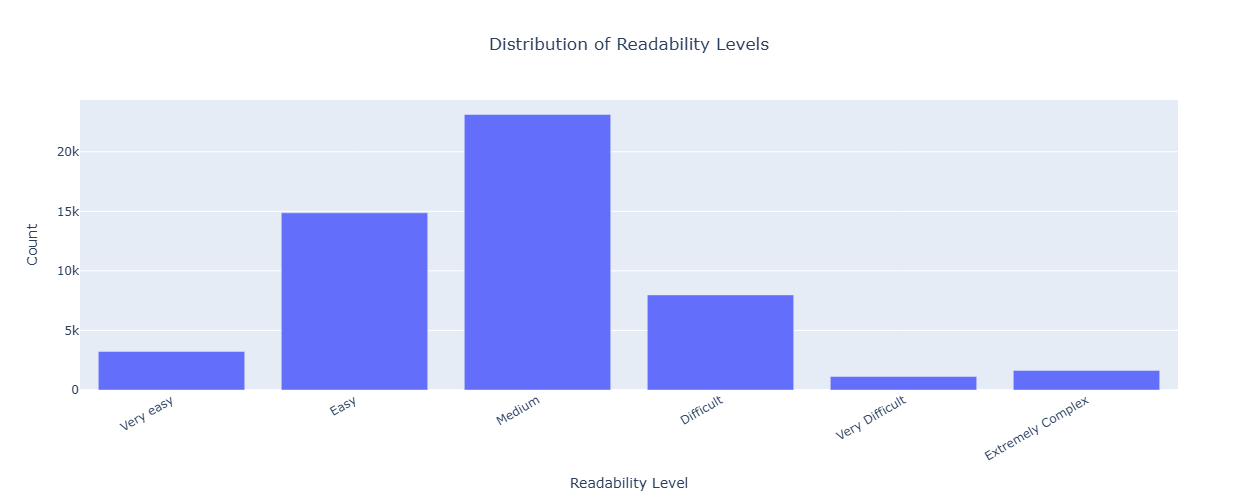

In [44]:
order = ["Very easy", "Easy", "Medium", "Difficult", "Very Difficult", "Extremely Complex"]

readability_counts = df["Prompt_readability_level"].value_counts().reindex(order).reset_index()
readability_counts.columns = ["Readability Level", "Count"]

fig3 = px.bar(
    readability_counts,
    x="Readability Level",
    y="Count",
    title="Distribution of Readability Levels",
    width=700,
    height=500
)

fig3.update_layout(
    title_x=0.5,
    xaxis_tickangle=-30
)

fig3.show()
fig3.write_image("distribution_of_readability_levels.png")

# 5. Do bigger prompts easier or longer answers?

In [45]:
(df["instruction"][0].split(' '))

['Give', 'three', 'tips', 'for', 'staying', 'healthy.']

In [46]:
df["instruction_word_count"]=df["instruction"].apply(lambda x: len(x.split(' ')))
df["instruction_word_count"]

0         6
1         6
2         6
3         6
4        11
         ..
51997    13
51998    13
51999     8
52000    16
52001    10
Name: instruction_word_count, Length: 52002, dtype: int64

(-200.0, 150.0)

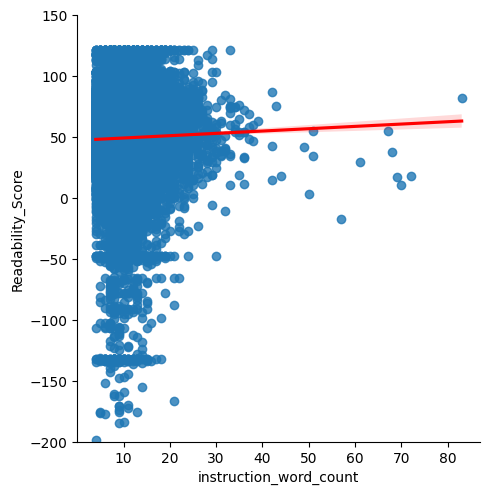

In [47]:
sns.lmplot(data=df,
           x="instruction_word_count",
           y="Readability_Score",
          line_kws={"color":"red"})
plt.ylim(-200,150)

### 5.1 Analysing Mathematically

In [48]:
#y=m*x+c
m,c=np.polyfit(df["instruction_word_count"],df["Readability_Score"],1)
print(m,c)

0.19079426019448847 47.164124076177806


In [49]:
df["instruction_word_count"].corr(df["Readability_Score"])

0.021566631055571016

##### A low correlation value means that the length of prompt doesn't affect the prompt's complexity

In [50]:
!pip install statsmodels

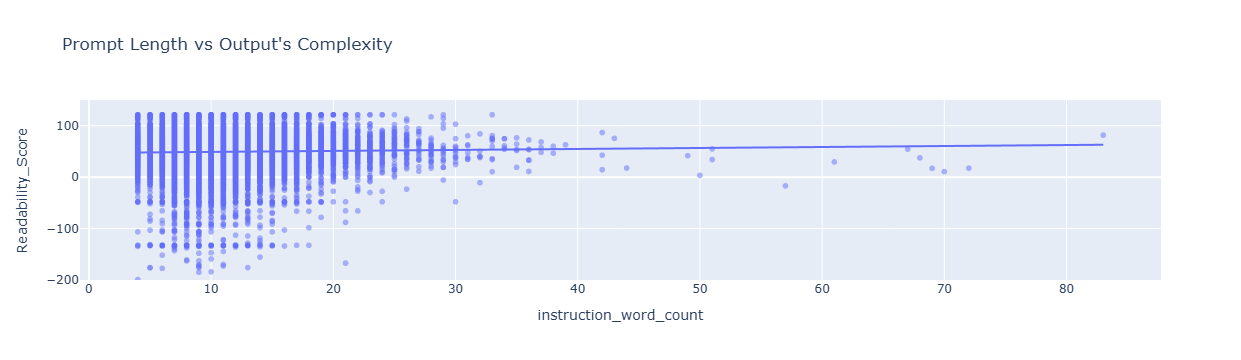

In [51]:
fig=px.scatter(df,
           x="instruction_word_count",
           y="Readability_Score",
          title="Prompt Length vs Output's Complexity",
          opacity=0.5,
          trendline="ols")

fig.update_layout(
    yaxis=dict(range=[-200, 150]))

fig.show()
fig.write_image("length_vs_complexity.png")

# 6. How Verbose are ChatGPT's responses?

In [52]:
def count_sentences(text):
    text=str(text)
    sentences=re.split(r'[.?!]',text)
    sentences=[s.strip() for s in sentences if s.strip()]
    return len(sentences)

In [53]:
df["sentence_count"]=df["output"].apply(count_sentences)

In [54]:
#no of words
len(df["output"][0].split())

121

In [55]:
df["output_word_count"]=df["output"].apply(lambda x: len(x.split()))

In [56]:
df["words_per_sentence"]=df["output_word_count"]/df["sentence_count"]
df["words_per_sentence"]

0        12.100000
1        17.666667
2        19.000000
3        12.705882
4        21.000000
           ...    
51997    38.666667
51998     3.000000
51999    27.333333
52000    13.631579
52001    23.000000
Name: words_per_sentence, Length: 52002, dtype: float64

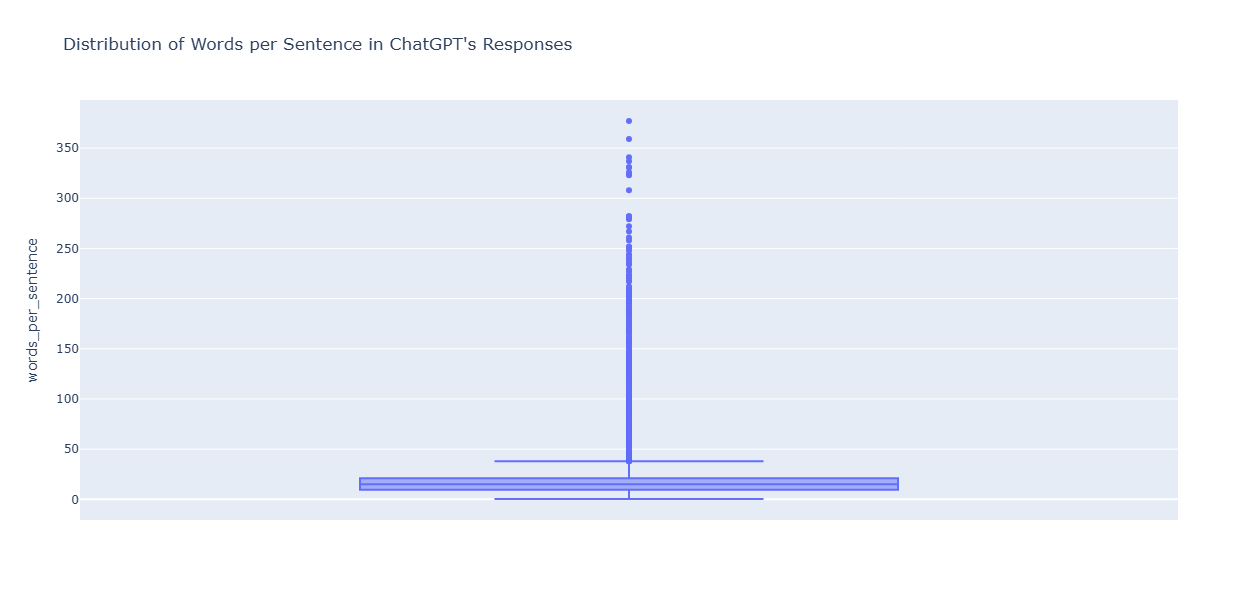

In [57]:
fig=px.box(df, 
       y="words_per_sentence",
       title="Distribution of Words per Sentence in ChatGPT's Responses",
       width=900,
       height=600)

fig.show()
fig2.write_image("verbosity_of_prompts.png")

# 7. Does adding additional content improves ChatGPT's responses?

In [58]:
df.tail()

,instruction,input,output,text,prompt_type,Readability_Score,Prompt_readability_level,instruction_word_count,sentence_count,output_word_count,words_per_sentence
51997,Generate an example of what a resume should li...,,**John Doe**\n\n**Contact Information:**\n\n12...,Below is an instruction that describes a task....,Creative Task,-9.244632,Extremely Complex,13,6,232,38.666667
51998,Arrange the items given below in the order to ...,"cake, me, eating",Me eating cake.,"Below is an instruction that describes a task,...",Other,90.990000,Very easy,13,1,3,3.000000
51999,Write an introductory paragraph about a famous...,Michelle Obama,"Michelle Obama, born January 17, 1964, in Chic...","Below is an instruction that describes a task,...",Creative Task,26.398984,Difficult,8,3,82,27.333333
52000,Generate a list of five things one should keep...,,1. Evaluate your reasons: It's important to ta...,Below is an instruction that describes a task....,Creative Task,55.441284,Medium,16,19,259,13.631579
52001,Analyze the given legal document and explain t...,The following is an excerpt from a contract be...,The contract between Company A and Company B o...,"Below is an instruction that describes a task,...",Other,15.209565,Difficult,10,4,92,23.000000


In [59]:
df["has_extra_context"]=df["input"].apply(lambda x : 0 if pd.isna(x) or x.strip()=="" else 1)

In [60]:
df["has_extra_context"].value_counts()

has_extra_context
0    31323
1    20679
Name: count, dtype: int64

In [61]:
comparison=df.groupby(["has_extra_context"])[["output_word_count","Readability_Score"]].mean().reset_index()

In [62]:
comparison

,has_extra_context,output_word_count,Readability_Score
0,0,138.477125,46.355954
1,1,66.073359,53.211004


In [63]:
comparison["Context"]=comparison["has_extra_context"].map({0:"No Extra Content",1:"Has Extra Content"})
comparison

,has_extra_context,output_word_count,Readability_Score,Context
0,0,138.477125,46.355954,No Extra Content
1,1,66.073359,53.211004,Has Extra Content


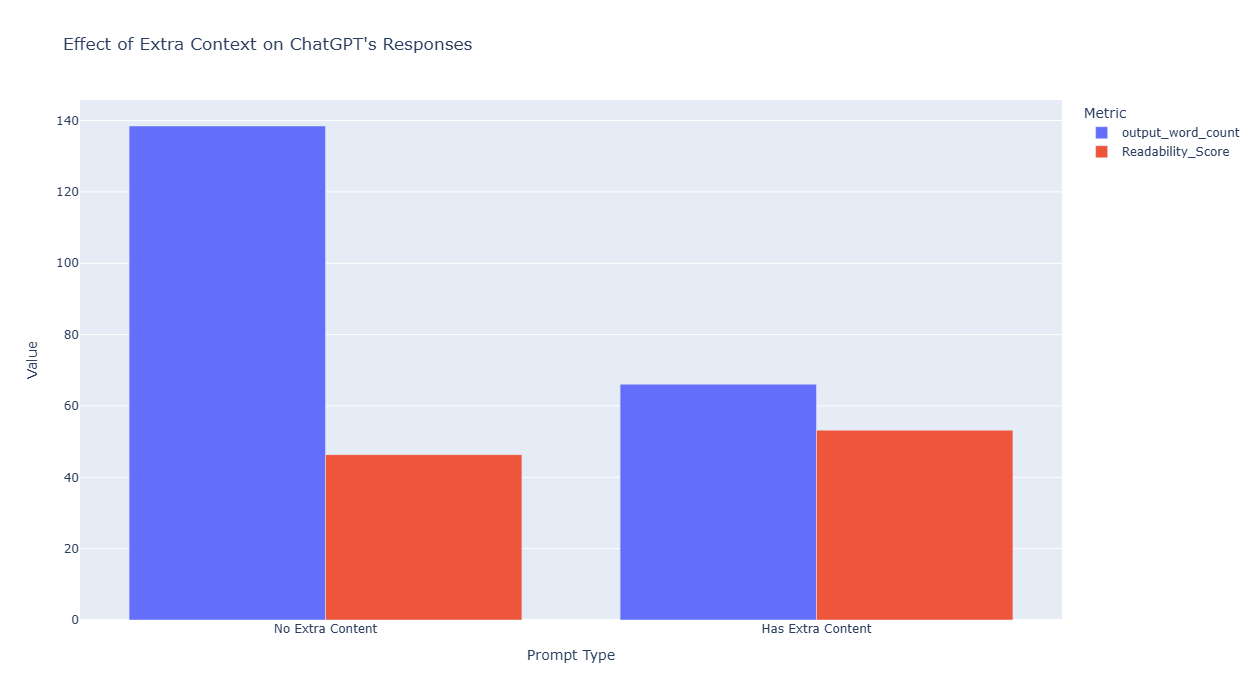

In [64]:
comparison_melted = comparison.melt(
    id_vars="Context",
    value_vars=["output_word_count", "Readability_Score"],
    var_name="Metric",
    value_name="Value"
)

fig = px.bar(
    comparison_melted,
    x="Context",
    y="Value",
    color="Metric",
    barmode="group",
    title="Effect of Extra Context on ChatGPT's Responses",
    height=700,
    width=1000,
    labels={
        "value":"Average Value",
        "variable":"Metric",
        "Context":"Prompt Type"
    }
)

fig.show()
fig.write_image("Extra_content_effect.png")

In [65]:
df.columns

Index(['instruction', 'input', 'output', 'text', 'prompt_type',
       'Readability_Score', 'Prompt_readability_level',
       'instruction_word_count', 'sentence_count', 'output_word_count',
       'words_per_sentence', 'has_extra_context'],
      dtype='object')

In [66]:
df.to_csv("data.csv", index=False)

In [69]:
df.to_csv("data.csv.gz", index=False, compression="gzip")